# Pretrained EfficientNetB0 for HAM10000 Skin-Lesion Classification

Train and evaluate an ImageNet-pretrained EfficientNetB0 classifier for the seven HAM10000 diagnosis classes. Partitions are stratified by diagnosis and grouped by `lesion_id`, so images of the same lesion cannot cross training, validation, and test sets.


## Environment and experiment configuration


In [1]:
import os
import time
import random
import zipfile
import platform
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
)

from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 16
HEAD_EPOCHS = 15
FINE_TUNE_EPOCHS = 15
FINE_TUNE_LAYERS = 30

tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

print(f"Python: {platform.python_version()}")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")


Python: 3.12.13
TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data acquisition and indexing


In [2]:
DATASET_HANDLE = "kmader/skin-cancer-mnist-ham10000"

data_path = kagglehub.dataset_download(DATASET_HANDLE)
metadata_path = Path(data_path) / "HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

print(f"Dataset directory: {data_path}")
print(f"Metadata shape: {df.shape}")
display(df.head())


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset directory: /kaggle/input/skin-cancer-mnist-ham10000
Metadata shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
part1_dir = Path(data_path) / "HAM10000_images_part_1"
part2_dir = Path(data_path) / "HAM10000_images_part_2"

for image_dir, archive_name in [
    (part1_dir, "HAM10000_images_part_1.zip"),
    (part2_dir, "HAM10000_images_part_2.zip"),
]:
    if not image_dir.is_dir():
        archive_path = Path(data_path) / archive_name
        if not archive_path.exists():
            raise FileNotFoundError(
                f"Neither {image_dir} nor {archive_path} was found."
            )
        print(f"Extracting {archive_name}...")
        with zipfile.ZipFile(archive_path, "r") as archive:
            archive.extractall(data_path)

path_lookup = {
    image_path.stem: str(image_path)
    for image_dir in (part1_dir, part2_dir)
    for image_path in image_dir.glob("*.jpg")
}

df["image_path"] = df["image_id"].map(path_lookup)
missing_paths = df["image_path"].isna().sum()

if missing_paths:
    raise ValueError(f"{missing_paths} metadata rows have no matching image file.")

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])

class_names = label_encoder.classes_
num_classes = len(class_names)

print(f"Indexed images: {len(df):,}")
print(f"Classes ({num_classes}): {list(class_names)}")


Indexed images: 10,015
Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,class,count,percent
0,akiec,327,3.27%
1,bcc,514,5.13%
2,bkl,1099,10.97%
3,df,115,1.15%
4,mel,1113,11.11%
5,nv,6705,66.95%
6,vasc,142,1.42%


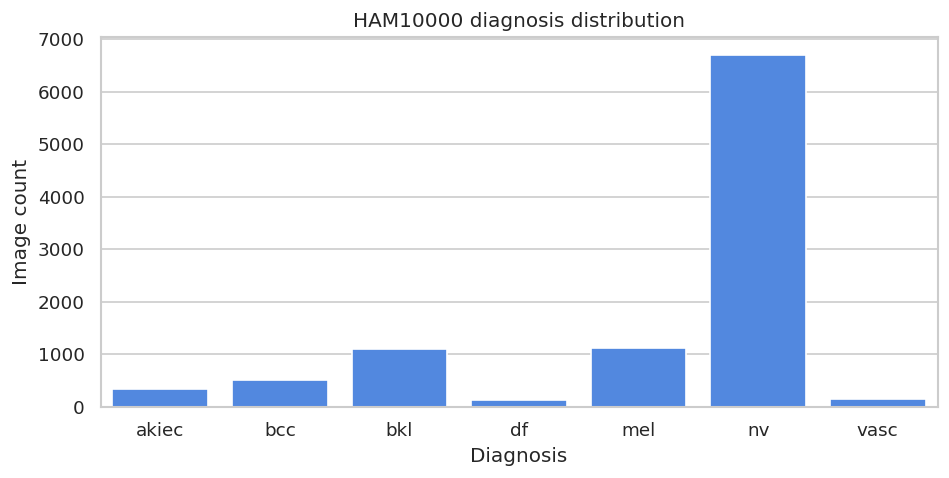

In [4]:
class_distribution = (
    df["dx"]
    .value_counts()
    .reindex(class_names)
    .rename_axis("class")
    .reset_index(name="count")
)
class_distribution["percent"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
)

display(class_distribution.style.format({"percent": "{:.2f}%"}))

plt.figure(figsize=(9, 4))
sns.barplot(data=class_distribution, x="class", y="count", color="#3b82f6")
plt.title("HAM10000 diagnosis distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Image count")
plt.show()


## Lesion-disjoint stratified train, validation, and test partitions


In [5]:
labels = df["label"].to_numpy()
groups = df["lesion_id"].to_numpy()
all_indices = np.arange(len(df))

# One of five outer folds is the test set: approximately 20%.
outer_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)
train_val_idx, test_idx = next(
    outer_splitter.split(
        all_indices,
        y=labels,
        groups=groups,
    )
)

train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# One of ten inner folds is validation: approximately 10% of the
# remaining 80%, or 8% of the complete dataset.
inner_splitter = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED,
)
train_idx, val_idx = next(
    inner_splitter.split(
        train_val_df.index,
        y=train_val_df["label"],
        groups=train_val_df["lesion_id"],
    )
)

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

paths_train = train_df["image_path"].to_numpy()
y_train = train_df["label"].to_numpy()
paths_val = val_df["image_path"].to_numpy()
y_val = val_df["label"].to_numpy()
paths_test = test_df["image_path"].to_numpy()
y_test = test_df["label"].to_numpy()

train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

assert train_lesions.isdisjoint(val_lesions)
assert train_lesions.isdisjoint(test_lesions)
assert val_lesions.isdisjoint(test_lesions)

split_sizes = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "images": [len(train_df), len(val_df), len(test_df)],
        "lesions": [
            train_df["lesion_id"].nunique(),
            val_df["lesion_id"].nunique(),
            test_df["lesion_id"].nunique(),
        ],
    }
)
split_sizes["image_percent"] = split_sizes["images"] / len(df) * 100

display(split_sizes.style.format({"image_percent": "{:.2f}%"}))
print("Lesion overlap checks passed: train, validation, and test are disjoint.")


,split,images,lesions,image_percent
0,train,7201,5377,71.90%
1,validation,800,598,7.99%
2,test,2014,1495,20.11%


Lesion overlap checks passed: train, validation, and test are disjoint.


In [6]:
def split_distribution(labels, split_name):
    counts = pd.Series(labels).value_counts().reindex(
        range(num_classes), fill_value=0
    )
    return pd.DataFrame(
        {
            "class": class_names,
            f"{split_name}_count": counts.to_numpy(),
            f"{split_name}_percent": (counts / counts.sum() * 100).to_numpy(),
        }
    ).set_index("class")


split_audit = (
    split_distribution(y_train, "train")
    .join(split_distribution(y_val, "validation"))
    .join(split_distribution(y_test, "test"))
)

display(
    split_audit.style.format(
        {
            "train_percent": "{:.2f}%",
            "validation_percent": "{:.2f}%",
            "test_percent": "{:.2f}%",
        }
    )
)


,train_count,train_percent,validation_count,validation_percent,test_count,test_percent
class,,,,,,
akiec,242,3.36%,17,2.12%,68,3.38%
bcc,375,5.21%,39,4.88%,100,4.97%
bkl,810,11.25%,84,10.50%,205,10.18%
df,83,1.15%,10,1.25%,22,1.09%
mel,805,11.18%,86,10.75%,222,11.02%
nv,4786,66.46%,556,69.50%,1363,67.68%
vasc,100,1.39%,8,1.00%,34,1.69%


## Streaming image pipeline

EfficientNetB0 includes its own rescaling layer. Images remain on the 0–255 scale in this pipeline; do not divide them by 255 again.


In [7]:
def decode_and_resize(image_path, label):
    image_bytes = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE), antialias=True)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(paths, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(paths), 2048),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        decode_and_resize,
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = make_dataset(paths_train, y_train, training=True)
val_ds = make_dataset(paths_val, y_val)
test_ds = make_dataset(paths_test, y_test)

sample_images, sample_labels = next(iter(train_ds))
print("Batch image shape:", sample_images.shape)
print("Batch label shape:", sample_labels.shape)
print("Pixel range:", float(tf.reduce_min(sample_images)), "to", float(tf.reduce_max(sample_images)))


Batch image shape: (16, 224, 224, 3)
Batch label shape: (16,)
Pixel range: 0.0 to 253.80255126953125


## Class weighting


In [8]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train,
)
class_weight_dict = dict(zip(range(num_classes), class_weights))

weight_table = pd.DataFrame(
    {
        "class": class_names,
        "train_images": [(y_train == index).sum() for index in range(num_classes)],
        "class_weight": class_weights,
    }
)

display(weight_table.style.format({"class_weight": "{:.3f}"}))


,class,train_images,class_weight
0,akiec,242,4.251
1,bcc,375,2.743
2,bkl,810,1.270
3,df,83,12.394
4,mel,805,1.278
5,nv,4786,0.215
6,vasc,100,10.287


## EfficientNetB0 transfer-learning model


In [9]:
augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="augmentation",
)

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
)
base_model.trainable = False

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="image")
x = augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.30, name="dropout")(x)
outputs = layers.Dense(
    num_classes,
    activation="softmax",
    name="diagnosis",
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_HAM10000",
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_HAM10000"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ diagnosis (Dense)               │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Stage 1: classification-head training


In [ ]:
head_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
    ),
    keras.callbacks.ModelCheckpoint(
        "efficientnetb0_lesion_split_head_best.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=head_callbacks,
    verbose=1,
)


Epoch 1/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 105s 194ms/step - accuracy: 0.5245 - loss: 1.4584 - val_accuracy: 0.5200 - val_loss: 1.3866 - learning_rate: 0.0010
Epoch 2/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 66s 146ms/step - accuracy: 0.6170 - loss: 1.1505 - val_accuracy: 0.6450 - val_loss: 1.1369 - learning_rate: 0.0010
Epoch 3/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 65s 145ms/step - accuracy: 0.6473 - loss: 1.0576 - val_accuracy: 0.6687 - val_loss: 0.9591 - learning_rate: 0.0010
Epoch 4/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - accuracy: 0.6691 - loss: 0.9705 - val_accuracy: 0.6825 - val_loss: 0.9364 - learning_rate: 0.0010
Epoch 5/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - accuracy: 0.6677 - loss: 0.9299 - val_accuracy: 0.6775 - val_loss: 0.9402 - learning_rate: 0.0010
Epoch 6/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 87s 157ms/step - accuracy: 0.6700 - loss: 0.9282 - val_accuracy: 0.6825 - val_loss: 0.9268 - learning_rate: 0.0010
Epoch 7/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 70s 154ms/step - accuracy: 0.

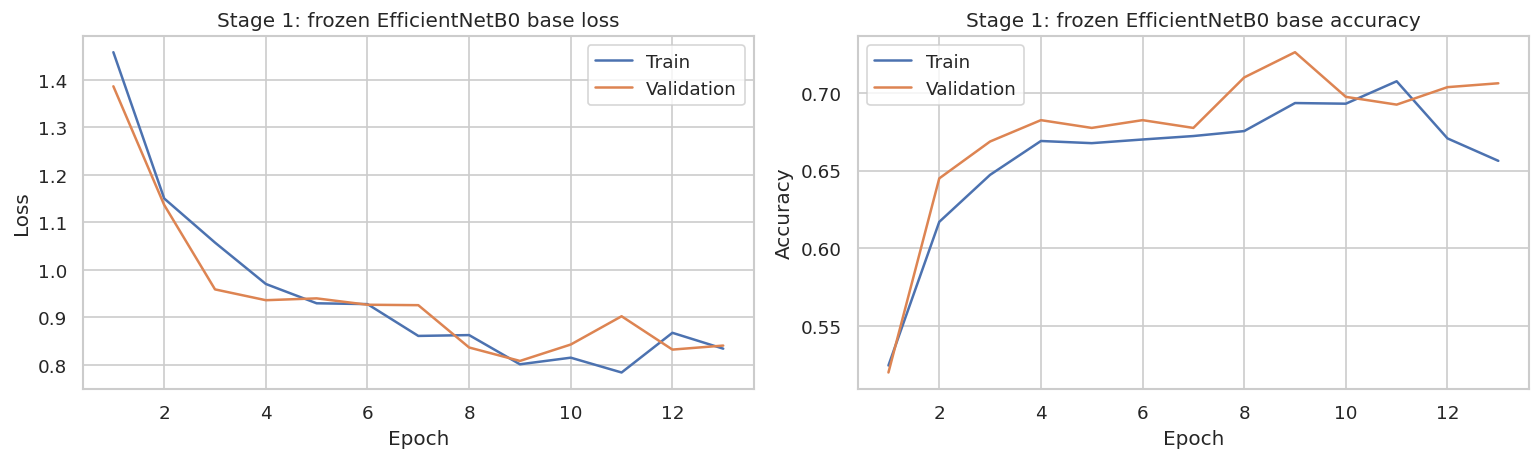

In [ ]:
def plot_history(history, title):
    history_frame = pd.DataFrame(history.history)
    epochs = np.arange(1, len(history_frame) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history_frame["loss"], label="Train")
    axes[0].plot(epochs, history_frame["val_loss"], label="Validation")
    axes[0].set(title=f"{title} loss", xlabel="Epoch", ylabel="Loss")
    axes[0].legend()

    axes[1].plot(epochs, history_frame["accuracy"], label="Train")
    axes[1].plot(epochs, history_frame["val_accuracy"], label="Validation")
    axes[1].set(title=f"{title} accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(history_head, "Stage 1: frozen EfficientNetB0 base")


## Stage 2: partial fine-tuning


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
    ),
    keras.callbacks.ModelCheckpoint(
        "efficientnetb0_lesion_split_finetuned_best.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]

history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=fine_tune_callbacks,
    verbose=1,
)


In [ ]:
plot_history(history_fine_tune, "Stage 2: fine-tuned EfficientNetB0")


## Final held-out test evaluation


In [ ]:
test_probabilities = model.predict(test_ds, verbose=0)
y_pred = test_probabilities.argmax(axis=1)

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
macro_f1 = f1_score(y_test, y_pred, average="macro")
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
per_class_recall = recall_score(y_test, y_pred, average=None)

y_test_one_hot = label_binarize(
    y_test,
    classes=np.arange(num_classes),
)
macro_roc_auc = roc_auc_score(
    y_test_one_hot,
    test_probabilities,
    average="macro",
    multi_class="ovr",
)

metrics_table = pd.DataFrame(
    {
        "metric": [
            "Test loss",
            "Test accuracy",
            "Macro F1",
            "Balanced accuracy",
            "Macro ROC-AUC (OvR)",
        ],
        "value": [
            test_loss,
            test_accuracy,
            macro_f1,
            balanced_accuracy,
            macro_roc_auc,
        ],
    }
)

display(metrics_table.style.format({"value": "{:.4f}"}))

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=3,
    )
)


In [ ]:
per_class_metrics = pd.DataFrame(
    {
        "class": class_names,
        "test_images": [(y_test == index).sum() for index in range(num_classes)],
        "recall": per_class_recall,
    }
)

display(per_class_metrics.style.format({"recall": "{:.4f}"}))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

confusion = confusion_matrix(y_test, y_pred)
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
)
axes[0].set(
    title="EfficientNetB0: test confusion matrix",
    xlabel="Predicted",
    ylabel="Actual",
)

normalized_confusion = confusion.astype(float) / confusion.sum(
    axis=1,
    keepdims=True,
)
sns.heatmap(
    normalized_confusion,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
)
axes[1].set(
    title="EfficientNetB0: normalized test confusion matrix",
    xlabel="Predicted",
    ylabel="Actual",
)

plt.tight_layout()
plt.show()


## Model-size and inference-latency benchmark


In [ ]:
MODEL_PATH = "efficientnetb0_ham10000_lesion_split_final.keras"
model.save(MODEL_PATH)

benchmark_images, _ = next(iter(test_ds))

for _ in range(3):
    _ = model(benchmark_images, training=False)

timings = []
for _ in range(10):
    start = time.perf_counter()
    _ = model(benchmark_images, training=False)
    timings.append(time.perf_counter() - start)

model_size_mb = Path(MODEL_PATH).stat().st_size / (1024 ** 2)
median_ms_per_image = np.median(timings) / len(benchmark_images) * 1000

benchmark_table = pd.DataFrame(
    [
        {
            "model": "EfficientNetB0 (ImageNet pretrained)",
            "split_protocol": "StratifiedGroupKFold by lesion_id",
            "parameters": model.count_params(),
            "test_accuracy": test_accuracy,
            "macro_f1": macro_f1,
            "balanced_accuracy": balanced_accuracy,
            "macro_roc_auc": macro_roc_auc,
            "saved_model_mb": model_size_mb,
            "median_inference_ms_per_image": median_ms_per_image,
        }
    ]
)

display(
    benchmark_table.style.format(
        {
            "test_accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "macro_roc_auc": "{:.4f}",
            "saved_model_mb": "{:.2f}",
            "median_inference_ms_per_image": "{:.2f}",
        }
    )
)

benchmark_table.to_csv("efficientnetb0_lesion_split_benchmark.csv", index=False)
per_class_metrics.to_csv("efficientnetb0_lesion_split_per_class_metrics.csv", index=False)

print(f"Saved model: {MODEL_PATH}")
print("Saved metrics: efficientnetb0_lesion_split_benchmark.csv")
print("Saved per-class metrics: efficientnetb0_lesion_split_per_class_metrics.csv")


## Result record

This experiment uses diagnosis-stratified, lesion-disjoint partitions. Images sharing a `lesion_id` cannot appear in more than one split.

Results from the earlier image-level split are not directly comparable unless the ANN and CNN baselines are retrained on these same lesion-level partitions. Report the split protocol with every benchmark result.

This notebook evaluates image classification performance only. It is not a diagnostic system and must not be used for clinical decision-making.
